## Exploració i neteja del dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("insurance_claims.csv")
df_work = df.copy()

print("Shape inicial:", df_work.shape)
print("\nInfo inicial:")
print(df_work.info())

Shape inicial: (1000, 40)

Info inicial:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 no

### Exploració bàsica

En aquesta primera fase fem una inspecció general del dataset per entendre com està estructurat i detectar possibles problemes
abans de començar la neteja i la preparació per al model. Concretament, revisem:

- les primeres files, per veure l'aspecte general de les dades
- els tipus de dades de cada variable
- la presència de valors nuls
- l’existència de duplicats exactes
  
Aquesta exploració inicial és important perquè ens permet identificar errors, columnes sospitoses o variables que necessitaran tractament específic abans de l’anàlisi predictiva.

In [ ]:
print("\nPrimeres files:")
print(df_work.head())

print("\nTipus de dades:")
print(df_work.dtypes)

print("\nValors nuls:")
print(df_work.isnull().sum().sort_values(ascending=False))

print("\nDuplicats exactes:")
print(df_work.duplicated().sum())


Primeres files:
   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... police_report_available total_claim_amount injury_claim  \
0       

Una primera revisió del dataset mostra que l’estructura general és coherent i adequada per a un problema de detecció de frau. Les variables combinen informació de la pòlissa, l’assegurat, l’incident i l’import reclamat, fet que permet una anàlisi prou completa del cas.

Pel que fa a la qualitat de les dades, es detecta una columna completament buida (_c39), que no aporta informació útil, i una variable amb valors nuls (authorities_contacted) que haurà de ser tractada més endavant. També s’observa que algunes dates encara estan en format object, per la qual cosa caldrà transformar-les abans de l’anàlisi. Finalment, no s’han trobat duplicats exactes, cosa que indica que no hi ha registres repetits de manera literal.

### Eliminació de columnes inútils

En aquest pas s’eliminen aquelles columnes que, després de l’exploració inicial, s’han considerat poc útils per al model. L’objectiu és reduir soroll i quedar-nos només amb variables que puguin aportar informació rellevant per a la predicció del frau.

In [ ]:
# _c39 està completament buida
if "_c39" in df_work.columns:
    df_work.drop(columns=["_c39"], inplace=True)

# policy_number sembla identificador, no predictor útil
if "policy_number" in df_work.columns:
    df_work.drop(columns=["policy_number"], inplace=True)

print("\nShape després d'eliminar columnes inútils:", df_work.shape)


Shape després d'eliminar columnes inútils: (1000, 38)


### Detectar "?" i altres possibles missing disfressats

En aquesta fase es revisen els valors categòrics per detectar possibles valors absents que no apareixen com a NaN, sinó representats amb símbols o textos especials, com ara ?. Aquesta comprovació és important perquè aquests valors poden passar desapercebuts en una revisió estàndard de missing values i afectar tant la neteja com la interpretació posterior del model.

In [ ]:
print("\nComptatge de '?' per columnes object:")
for col in df_work.select_dtypes(include="object").columns:
    n_q = (df_work[col].astype(str).str.strip() == "?").sum()
    print(f"{col}: {n_q}")

print("\nValue counts de columnes object:")
for col in df_work.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df_work[col].astype(str).str.strip().value_counts(dropna=False).head(15))


Comptatge de '?' per columnes object:
policy_bind_date: 0
policy_state: 0
policy_csl: 0
insured_sex: 0
insured_education_level: 0
insured_occupation: 0
insured_hobbies: 0
insured_relationship: 0
incident_date: 0
incident_type: 0
collision_type: 178
incident_severity: 0
authorities_contacted: 0
incident_state: 0
incident_city: 0
incident_location: 0
property_damage: 360
police_report_available: 343
auto_make: 0
auto_model: 0
fraud_reported: 0

Value counts de columnes object:

--- policy_bind_date ---
policy_bind_date
2006-01-01    3
1992-04-28    3
1992-08-05    3
1991-12-14    2
2004-08-09    2
2010-01-28    2
1999-09-29    2
2001-09-25    2
2000-05-04    2
1997-02-03    2
1999-04-07    2
2013-12-25    2
1991-12-28    2
1993-08-30    2
2005-09-21    2
Name: count, dtype: int64

--- policy_state ---
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

--- policy_csl ---
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64

--- insured_s

Aquesta anàlisi mostra que alguns valors ? actuen com a possibles missing disfressats, especialment a collision_type, property_damage i police_report_available. També es confirma que authorities_contacted conté valors nuls reals. Per tant, abans de modelar cal estudiar el significat d’aquests símbols per decidir si representen informació desconeguda, una categoria específica o un valor no aplicable.

### Revisar el significat de "?"

Després de detectar la presència de ? en algunes variables, es fa una anàlisi creuada amb incident_type per entendre millor el seu significat. L’objectiu és distingir si aquests valors representen realment dades absents o bé una categoria amb sentit dins del context de l’incident.

In [ ]:
print("\nCrosstab incident_type vs collision_type:")
print(pd.crosstab(df_work["incident_type"], df_work["collision_type"], margins=True))

print("\nCrosstab incident_type vs property_damage:")
print(pd.crosstab(df_work["incident_type"], df_work["property_damage"], margins=True))

print("\nCrosstab incident_type vs police_report_available:")
print(pd.crosstab(df_work["incident_type"], df_work["police_report_available"], margins=True))


Crosstab incident_type vs collision_type:
collision_type              ?  Front Collision  Rear Collision  \
incident_type                                                    
Multi-vehicle Collision     0              115             152   
Parked Car                 84                0               0   
Single Vehicle Collision    0              139             140   
Vehicle Theft              94                0               0   
All                       178              254             292   

collision_type            Side Collision   All  
incident_type                                   
Multi-vehicle Collision              152   419  
Parked Car                             0    84  
Single Vehicle Collision             124   403  
Vehicle Theft                          0    94  
All                                  276  1000  

Crosstab incident_type vs property_damage:
property_damage             ?   NO  YES   All
incident_type                                
Multi-vehicle C

Els resultats mostren que, en el cas de collision_type, el valor ? no sembla un missing real, sinó una categoria no aplicable, ja que només apareix en incidents de tipus Parked Car i Vehicle Theft, on no hi ha col·lisió pròpiament dita. En canvi, a property_damage i police_report_available, el valor ? apareix repartit en tots els tipus d’incident, fet que suggereix que en aquests casos s’interpreta millor com a informació desconeguda o no informada.

### Neteja de valors especials

Un cop interpretat el significat dels valors especials, es procedeix a la seva recodificació per deixar el dataset en un format més coherent i fàcil de tractar. Aquesta neteja permet diferenciar entre categories no aplicables i informació desconeguda, evitant que aquests valors quedin representats de manera ambigua.

In [ ]:
# collision_type: ? = categoria amb significat ("Not Applicable")
df_work["collision_type"] = df_work["collision_type"].replace("?", "Not Applicable")

# property_damage i police_report_available: ? = desconegut/no informat
df_work["property_damage"] = df_work["property_damage"].replace("?", "Unknown")
df_work["police_report_available"] = df_work["police_report_available"].replace("?", "Unknown")

# authorities_contacted: NaN real -> Unknown
df_work["authorities_contacted"] = df_work["authorities_contacted"].fillna("Unknown")

print("\nValors nuls després de tractar '?' i NaN:")
print(df_work.isnull().sum().sort_values(ascending=False))


Valors nuls després de tractar '?' i NaN:
months_as_customer             0
witnesses                      0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
police_report_available        0
age                            0
total_claim_amount             0
injury_claim                   0
property_claim                 0
vehicle_claim                  0
auto_make                      0
auto_model                     0
auto_year                      0
authorities_contacted          0
incident_severity              0
collision_type                 0
incident_type                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0


Després d’aquesta recodificació, totes les variables queden sense valors nuls explícits. A més, s’ha preservat el significat dels valors especials: collision_type es tracta com una categoria no aplicable, mentre que property_damage, police_report_available i authorities_contacted recullen casos de valor desconegut o no informat.

### Convertir la variable objectiu a binària

Per poder aplicar tècniques de machine learning, la variable objectiu s’ha de transformar a format numèric. En aquest cas, fraud_reported es recodifica en una variable binària, on 1 indica frau i 0 absència de frau. A més, es revisa la seva distribució per conèixer el balanç entre classes.

In [ ]:
df_work["fraud_binary"] = df_work["fraud_reported"].map({"Y": 1, "N": 0})

print("\nDistribució de fraud_reported:")
print(df_work["fraud_reported"].value_counts(dropna=False))

print("\nDistribució de fraud_binary:")
print(df_work["fraud_binary"].value_counts(dropna=False))

print("\nPercentatge de frau:")
print(df_work["fraud_binary"].value_counts(normalize=True) * 100)


Distribució de fraud_reported:
fraud_reported
N    753
Y    247
Name: count, dtype: int64

Distribució de fraud_binary:
fraud_binary
0    753
1    247
Name: count, dtype: int64

Percentatge de frau:
fraud_binary
0    75.3
1    24.7
Name: proportion, dtype: float64


La variable objectiu s’ha convertit correctament a format binari, mantenint la mateixa distribució que la variable original. També s’observa que el dataset està desbalancejat, amb un 24,7% de casos de frau i un 75,3% de casos no fraudulents, fet que caldrà tenir en compte durant l’entrenament i l’avaluació del model.

### Convertir dates

Les variables temporals es converteixen a format datetime per poder-les treballar correctament en passos posteriors. Aquesta transformació és necessària per extreure informació rellevant, com ara l’antiguitat de la pòlissa o característiques del moment en què es produeix l’incident.

In [ ]:
df_work["policy_bind_date"] = pd.to_datetime(df_work["policy_bind_date"], errors="coerce")
df_work["incident_date"] = pd.to_datetime(df_work["incident_date"], errors="coerce")

print("\nMissing després de convertir dates:")
print(df_work[["policy_bind_date", "incident_date"]].isnull().sum())


Missing després de convertir dates:
policy_bind_date    0
incident_date       0
dtype: int64


La conversió de policy_bind_date i incident_date s’ha realitzat correctament, ja que no s’han generat valors nuls després del canvi de format. Això indica que totes dues columnes contenien dates vàlides i es podran utilitzar per crear noves variables temporals útils per al model.

### Crear variables derivades de data

A partir de les variables de data, es creen noves característiques que poden ser més informatives per al model que la data original en si mateixa. Aquest procés permet captar aspectes temporals rellevants, com l’antiguitat de la pòlissa, el mes de l’incident, el dia de la setmana o si el sinistre es va produir en cap de setmana.

In [ ]:
df_work["policy_age_days"] = (df_work["incident_date"] - df_work["policy_bind_date"]).dt.days
df_work["incident_month"] = df_work["incident_date"].dt.month
df_work["incident_dayofweek"] = df_work["incident_date"].dt.dayofweek
df_work["incident_is_weekend"] = df_work["incident_dayofweek"].isin([5, 6]).astype(int)
df_work["policy_bind_year"] = df_work["policy_bind_date"].dt.year
df_work["incident_year"] = df_work["incident_date"].dt.year

print("\nDescriptives variables de data derivades:")
print(df_work[[
    "policy_age_days",
    "incident_month",
    "incident_dayofweek",
    "incident_is_weekend"
]].describe())


Descriptives variables de data derivades:
       policy_age_days  incident_month  incident_dayofweek  \
count      1000.000000     1000.000000          1000.00000   
mean       4739.140000        1.496000             3.04700   
std        2686.430702        0.523697             1.97603   
min         -20.000000        1.000000             0.00000   
25%        2484.000000        1.000000             1.00000   
50%        4682.000000        1.000000             3.00000   
75%        7068.000000        2.000000             5.00000   
max        9172.000000        3.000000             6.00000   

       incident_is_weekend  
count          1000.000000  
mean              0.298000  
std               0.457608  
min               0.000000  
25%               0.000000  
50%               0.000000  
75%               1.000000  
max               1.000000  


Les noves variables temporals s’han generat correctament i aporten informació potencialment útil per al model. Tot i això, es detecta algun cas amb policy_age_days negativa, cosa que indica una possible inconsistència entre la data de contractació de la pòlissa i la data de l’incident, i que convé revisar en la fase de control de qualitat de les dades.

### Comprovar inconsistències bàsiques

Abans de continuar amb la preparació del dataset, es fa una comprovació d’inconsistències bàsiques per detectar possibles errors o valors incoherents. Aquesta revisió permet validar que les variables tinguin sentit des del punt de vista lògic i assegurar una millor qualitat de les dades abans del modelatge.

In [ ]:
print("\nCasos amb policy_age_days negativa:")
print((df_work["policy_age_days"] < 0).sum())

print("\nCasos amb age < 18:")
print((df_work["age"] < 18).sum())

print("\nCasos amb total_claim_amount diferent de la suma de components:")
claim_sum = df_work["injury_claim"] + df_work["property_claim"] + df_work["vehicle_claim"]
print((df_work["total_claim_amount"] != claim_sum).sum())


Casos amb policy_age_days negativa:
1

Casos amb age < 18:
0

Casos amb total_claim_amount diferent de la suma de components:
0


La revisió mostra que no hi ha casos amb edats inferiors a 18 anys i que total_claim_amount coincideix sempre amb la suma de injury_claim, property_claim i vehicle_claim, fet que confirma la consistència interna d’aquestes variables. Només es detecta un cas amb policy_age_days negativa, que podria correspondre a una incoherència puntual en les dates i que convindria revisar.

### Revisió de Cardinalitat de categòriques

També es revisa la cardinalitat de les variables categòriques, és a dir, el nombre de categories diferents que presenta cadascuna. Aquesta anàlisi és útil per identificar variables amb massa valors únics, ja que poden dificultar l’encoding, augmentar la dimensionalitat del dataset i reduir la interpretabilitat del model.

In [ ]:
print("\nNombre de categories per columna object:")
for col in df_work.select_dtypes(include="object").columns:
    print(f"{col}: {df_work[col].nunique()}")

# incident_location té cardinalitat molt alta; normalment l'exclouríem del model
if "incident_location" in df_work.columns:
    print("\nNombre de valors únics a incident_location:", df_work["incident_location"].nunique())


Nombre de categories per columna object:
policy_state: 3
policy_csl: 3
insured_sex: 2
insured_education_level: 7
insured_occupation: 14
insured_hobbies: 20
insured_relationship: 6
incident_type: 4
collision_type: 4
incident_severity: 4
authorities_contacted: 5
incident_state: 7
incident_city: 7
incident_location: 1000
property_damage: 3
police_report_available: 3
auto_make: 14
auto_model: 39
fraud_reported: 2

Nombre de valors únics a incident_location: 1000


La majoria de variables categòriques presenten una cardinalitat moderada i es poden tractar sense grans dificultats. En canvi, incident_location té 1000 valors únics, un per a cada registre, fet que indica una cardinalitat extremadament alta i suggereix que aquesta variable actua més com un identificador específic que no pas com una característica generalitzable, per la qual cosa és raonable excloure-la del model.

### Exploració de marques i models

La variable del vehicle pot aportar informació rellevant per al model, ja que tant la marca com el model poden estar relacionats amb el valor econòmic del cotxe i amb el tipus d’ús que se’n fa. Per aquest motiu, primer es fa una exploració de auto_make i auto_model per conèixer quines categories hi ha i com es combinen entre elles.

In [ ]:
### Revisar marques i models de vehicle
print("\nMarques úniques:")
print(sorted(df_work["auto_make"].dropna().unique()))

print("\nNombre de models únics:")
print(df_work["auto_model"].nunique())

print("\nModels únics ordenats:")
print(sorted(df_work["auto_model"].dropna().unique()))

print("\nTaula marca-model:")
print(pd.crosstab(df_work["auto_make"], df_work["auto_model"]))

print("\nCombinacions úniques marca-model:")
brand_model_pairs = (
    df_work[["auto_make", "auto_model"]]
    .drop_duplicates()
    .sort_values(["auto_make", "auto_model"])
)

print(brand_model_pairs.to_string(index=False))


Marques úniques:
['Accura', 'Audi', 'BMW', 'Chevrolet', 'Dodge', 'Ford', 'Honda', 'Jeep', 'Mercedes', 'Nissan', 'Saab', 'Suburu', 'Toyota', 'Volkswagen']

Nombre de models únics:
39

Models únics ordenats:
['3 Series', '92x', '93', '95', 'A3', 'A5', 'Accord', 'C300', 'CRV', 'Camry', 'Civic', 'Corolla', 'E400', 'Escape', 'F150', 'Forrestor', 'Fusion', 'Grand Cherokee', 'Highlander', 'Impreza', 'Jetta', 'Legacy', 'M5', 'MDX', 'ML350', 'Malibu', 'Maxima', 'Neon', 'Passat', 'Pathfinder', 'RAM', 'RSX', 'Silverado', 'TL', 'Tahoe', 'Ultima', 'Wrangler', 'X5', 'X6']

Taula marca-model:
auto_model  3 Series  92x  93  95  A3  A5  Accord  C300  CRV  Camry  ...  \
auto_make                                                            ...   
Accura             0    0   0   0   0   0       0     0    0      0  ...   
Audi               0    0   0   0  37  32       0     0    0      0  ...   
BMW               18    0   0   0   0   0       0     0    0      0  ...   
Chevrolet          0    0   0   0 

L’exploració mostra que hi ha 14 marques i 39 models diferents, amb combinacions coherents entre auto_make i auto_model. Aquesta revisió permet identificar els tipus de vehicles presents al dataset i serveix de base per crear noves variables més interpretables, com ara una classificació per gamma de preu o per tipus de vehicle.

### Crreacions de noves variables a partir de vehicle

Un cop revisades les categories disponibles, es creen noves variables derivades per resumir millor la informació del vehicle. En lloc de treballar només amb el model concret, es generen variables més generals que poden ser útils per al model i més fàcils d’interpretar, com ara si el vehicle és premium o quin tipus de vehicle representa.

In [ ]:
### Crear noves variables a partir de la marca i el model del vehicle

# Vehicles premium / no premium
premium_brands = ["Audi", "BMW", "Mercedes"]
premium_models = ["MDX", "TL", "C300", "E400", "ML350", "M5", "X5", "X6", "A3", "A5", "3 Series"]

df_work["is_premium"] = np.where(
    df_work["auto_make"].isin(premium_brands) | df_work["auto_model"].isin(premium_models),
    1,
    0
)

df_work["car_price_category"] = np.where(
    df_work["is_premium"] == 1,
    "Expensive",
    "Not Expensive"
)

# Tipus general de vehicle
sports_models = ["M5", "A5", "RSX", "93", "95", "92x"]
suv_models = ["MDX", "CRV", "Grand Cherokee", "Wrangler", "ML350", "X5", "X6", "Pathfinder", "Forrestor", "Highlander", "Escape", "Tahoe"]
pickup_models = ["F150", "RAM", "Silverado"]
sedan_models = ["3 Series", "A3", "C300", "E400", "TL", "Maxima", "Ultima", "Accord", "Civic", "Camry", "Corolla", "Jetta", "Passat", "Fusion", "Malibu", "Legacy", "Impreza", "Neon"]

def classify_vehicle_type(model):
    if model in sports_models:
        return "Sports"
    elif model in suv_models:
        return "SUV"
    elif model in pickup_models:
        return "Pickup"
    elif model in sedan_models:
        return "Sedan"
    else:
        return "Other"

df_work["vehicle_type"] = df_work["auto_model"].apply(classify_vehicle_type)

print("\nDistribució de is_premium:")
print(df_work["is_premium"].value_counts())

print("\nDistribució de car_price_category:")
print(df_work["car_price_category"].value_counts())

print("\nDistribució de vehicle_type:")
print(df_work["vehicle_type"].value_counts())

print("\nComprovació de classificació vehicle:")
print(
    df_work[["auto_make", "auto_model", "is_premium", "car_price_category", "vehicle_type"]]
    .drop_duplicates()
    .sort_values(["auto_make", "auto_model"])
    .to_string(index=False)
)


Distribució de is_premium:
is_premium
0    738
1    262
Name: count, dtype: int64

Distribució de car_price_category:
car_price_category
Not Expensive    738
Expensive        262
Name: count, dtype: int64

Distribució de vehicle_type:
vehicle_type
Sedan     458
SUV       311
Sports    139
Pickup     92
Name: count, dtype: int64

Comprovació de classificació vehicle:
 auto_make     auto_model  is_premium car_price_category vehicle_type
    Accura            MDX           1          Expensive          SUV
    Accura            RSX           0      Not Expensive       Sports
    Accura             TL           1          Expensive        Sedan
      Audi             A3           1          Expensive        Sedan
      Audi             A5           1          Expensive       Sports
       BMW       3 Series           1          Expensive        Sedan
       BMW             M5           1          Expensive       Sports
       BMW             X5           1          Expensive          SUV


A partir de auto_make i auto_model s’han creat noves variables que agrupen la informació del vehicle en categories més generals i interpretables. En concret, s’ha distingit entre vehicles premium i no premium, i també s’ha classificat cada model segons el seu tipus principal, com ara SUV, Pickup, Sedan o Sports. Aquesta transformació permet incorporar coneixement de domini i reduir el detall excessiu dels models individuals.

### Correlacions numèriques

En aquesta fase s’analitzen les correlacions entre les variables numèriques i la variable objectiu per identificar quines poden tenir una relació més directa amb el frau. A més, també es revisa la correlació entre les variables econòmiques de la reclamació per detectar possibles redundàncies o problemes de multicol·linearitat.

In [ ]:
df_corr = df_work.copy()

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr(numeric_only=True)

print("\nCorrelació amb fraud_binary (absoluta):")
corr_with_fraud = corr_matrix["fraud_binary"].abs().sort_values(ascending=False)
print(corr_with_fraud.head(15))

print("\nCorrelació entre variables de claims:")
cols_to_check = [
    "fraud_binary",
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim"
]
print(df_corr[cols_to_check].corr())


Correlació amb fraud_binary (absoluta):
fraud_binary                   1.000000
vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
is_premium                     0.054240
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
incident_is_weekend            0.032415
incident_month                 0.028847
months_as_customer             0.020544
insured_zip                    0.019368
capital-gains                  0.019173
Name: fraud_binary, dtype: float64

Correlació entre variables de claims:
                    fraud_binary  total_claim_amount  injury_claim  \
fraud_binary            1.000000            0.163651      0.090975   
total_claim_amount      0.163651            1.000000      0.805025   
injury_claim            0.090975            0.805025      1.000000   
prope

Les correlacions amb fraud_binary són baixes en general, tot i que les variables econòmiques de la reclamació són les que mostren una associació més alta. La variable is_premium també presenta una correlació positiva, però feble. A més, total_claim_amount està fortament correlacionada amb les seves components, de manera que és convenient eliminar-la per evitar redundància.

### Taules freqüència vs frau per categòriques importants

Finalment, s’analitza la distribució del frau dins d’algunes variables categòriques rellevants. Aquestes taules de freqüència permeten observar si determinades categories concentren proporcions més altes o més baixes de frau, i poden donar pistes útils sobre quines variables tenen més capacitat discriminativa.

In [ ]:
cat_cols_to_review = [
    "incident_type",
    "collision_type",
    "incident_severity",
    "authorities_contacted",
    "property_damage",
    "police_report_available",
    "insured_hobbies",
    "auto_make"
]

for col in cat_cols_to_review:
    print(f"\n========== {col} ==========")
    print(pd.crosstab(df_work[col], df_work["fraud_reported"], normalize="index") * 100)


========== incident_type ==========
fraud_reported                    N          Y
incident_type                                 
Multi-vehicle Collision   72.792363  27.207637
Parked Car                90.476190   9.523810
Single Vehicle Collision  70.967742  29.032258
Vehicle Theft             91.489362   8.510638

========== collision_type ==========
fraud_reported           N          Y
collision_type                       
Front Collision  72.440945  27.559055
Not Applicable   91.011236   8.988764
Rear Collision   68.835616  31.164384
Side Collision   74.637681  25.362319

========== incident_severity ==========
fraud_reported             N          Y
incident_severity                      
Major Damage       39.492754  60.507246
Minor Damage       89.265537  10.734463
Total Loss         87.142857  12.857143
Trivial Damage     93.333333   6.666667

========== authorities_contacted ==========
fraud_reported                 N          Y
authorities_contacted                      
A

Les taules de freqüència mostren diferències clares en la proporció de frau entre categories, especialment en variables com incident_severity, incident_type, collision_type i authorities_contacted. Això indica que diverses variables categòriques poden ser rellevants per a la predicció. També s’observen diferències en property_damage, auto_make i insured_hobbies, tot i que en aquest últim cas cal interpretar els resultats amb cautela perquè alguns grups poden tenir pocs registres.

### Anàlisi de categories amb associació extrema amb el frau

En les taules de freqüència s’observa que algunes categories presenten una taxa de frau molt superior a la mitjana global del dataset. Aquest patró és especialment visible a la variable insured_hobbies, on categories com chess i cross-fit concentren percentatges de frau molt elevats.

Com que aquestes associacions no tenen una interpretació causal evident, es revisen amb més detall per determinar si poden correspondre a patrons reals del dataset, a efectes de mida mostral o a possibles biaixos/artificis de les dades. Aquesta anàlisi és important perquè els models més flexibles poden donar molta importància a aquestes categories.

In [ ]:
# Taxa global de frau
global_fraud_rate = df_work["fraud_binary"].mean()

print("Taxa global de frau:")
print(round(global_fraud_rate * 100, 2), "%")

# Resum per hobbies: nombre de casos i taxa de frau
hobby_summary = (
    df_work
    .groupby("insured_hobbies")["fraud_binary"]
    .agg(n="count", fraud_rate="mean")
    .sort_values("fraud_rate", ascending=False)
)

hobby_summary["fraud_rate_%"] = hobby_summary["fraud_rate"] * 100
hobby_summary["diff_vs_global_%"] = (
    hobby_summary["fraud_rate"] - global_fraud_rate
) * 100
hobby_summary["risk_ratio"] = hobby_summary["fraud_rate"] / global_fraud_rate

print("\nResum de frau per insured_hobbies:")
print(hobby_summary)

Taxa global de frau:
24.7 %

Resum de frau per insured_hobbies:
                  n  fraud_rate  fraud_rate_%  diff_vs_global_%  risk_ratio
insured_hobbies                                                            
chess            46    0.826087     82.608696         57.908696    3.344482
cross-fit        35    0.742857     74.285714         49.585714    3.007519
yachting         53    0.301887     30.188679          5.488679    1.222214
board-games      48    0.291667     29.166667          4.466667    1.180837
polo             47    0.276596     27.659574          2.959574    1.119821
reading          64    0.265625     26.562500          1.862500    1.075405
base-jumping     49    0.265306     26.530612          1.830612    1.074114
hiking           52    0.230769     23.076923         -1.623077    0.934288
paintball        57    0.228070     22.807018         -1.892982    0.923361
skydiving        49    0.224490     22.448980         -2.251020    0.908866
video-games      50    0

In [ ]:
print("\nTaula absoluta insured_hobbies vs fraud_binary:")
print(pd.crosstab(df_work["insured_hobbies"], df_work["fraud_binary"], margins=True))


Taula absoluta insured_hobbies vs fraud_binary:
fraud_binary       0    1   All
insured_hobbies                
base-jumping      36   13    49
basketball        28    6    34
board-games       34   14    48
bungie-jumping    47    9    56
camping           50    5    55
chess              8   38    46
cross-fit          9   26    35
dancing           38    5    43
exercise          46   11    57
golf              49    6    55
hiking            40   12    52
kayaking          49    5    54
movies            46    9    55
paintball         44   13    57
polo              34   13    47
reading           47   17    64
skydiving         38   11    49
sleeping          33    8    41
video-games       40   10    50
yachting          37   16    53
All              753  247  1000


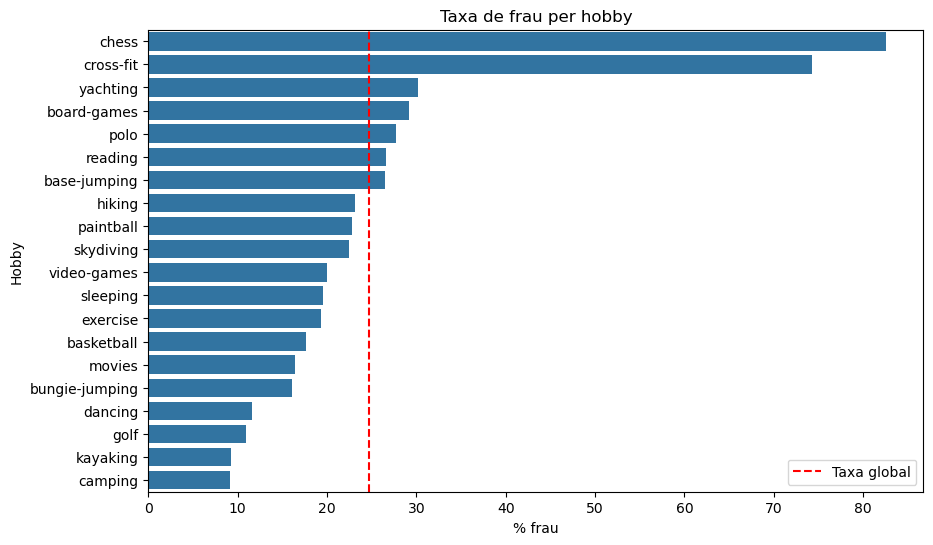

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hobby_plot = hobby_summary.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=hobby_plot,
    x="fraud_rate_%",
    y="insured_hobbies"
)
plt.axvline(global_fraud_rate * 100, color="red", linestyle="--", label="Taxa global")
plt.title("Taxa de frau per hobby")
plt.xlabel("% frau")
plt.ylabel("Hobby")
plt.legend()
plt.show()

La taxa global de frau és del 24,7%. En canvi, la categoria chess presenta una taxa de frau del 82,6% i cross-fit del 74,3%, molt per sobre de la mitjana. Aquest resultat explica per què insured_hobbies pot aparèixer com una variable molt important en els models.

Tot i això, aquesta relació s’ha d’interpretar amb cautela: el model detecta una associació estadística dins del dataset, però això no implica que el hobby sigui una causa del frau. En particular, la categoria chess no té una justificació causal clara en el context de detecció de frau d’assegurances, fet que suggereix que podria actuar com a patró artificial, biaix del dataset o proxy d’altres factors no observats.

In [ ]:
cat_cols = df_work.select_dtypes(include="object").columns.drop("fraud_reported")

category_risk_rows = []

for col in cat_cols:
    summary = (
        df_work
        .groupby(col)["fraud_binary"]
        .agg(n="count", fraud_rate="mean")
        .reset_index()
    )
    summary["variable"] = col
    summary["category"] = summary[col]
    summary["fraud_rate_%"] = summary["fraud_rate"] * 100
    summary["diff_vs_global_%"] = (summary["fraud_rate"] - global_fraud_rate) * 100
    summary["risk_ratio"] = summary["fraud_rate"] / global_fraud_rate

    category_risk_rows.append(
        summary[["variable", "category", "n", "fraud_rate_%", "diff_vs_global_%", "risk_ratio"]]
    )

category_risk_summary = pd.concat(category_risk_rows, ignore_index=True)

category_risk_summary.sort_values(
    ["risk_ratio", "n"],
    ascending=[False, False]
).head(30)

,variable,category,n,fraud_rate_%,diff_vs_global_%,risk_ratio
86,incident_location,1012 5th Lane,1,100.0,75.3,4.048583
88,incident_location,1030 Pine Lane,1,100.0,75.3,4.048583
98,incident_location,1173 Andromedia Ave,1,100.0,75.3,4.048583
102,incident_location,1218 Sky Hwy,1,100.0,75.3,4.048583
104,incident_location,1229 5th Ave,1,100.0,75.3,4.048583
108,incident_location,1269 Flute Drive,1,100.0,75.3,4.048583
109,incident_location,1273 Rock Lane,1,100.0,75.3,4.048583
112,incident_location,1306 Andromedia St,1,100.0,75.3,4.048583
114,incident_location,1320 Flute Lane,1,100.0,75.3,4.048583
116,incident_location,1328 Texas Lane,1,100.0,75.3,4.048583


In [ ]:
category_risk_summary[
    category_risk_summary["n"] >= 20
].sort_values("risk_ratio", ascending=False).head(30)

,variable,category,n,fraud_rate_%,diff_vs_global_%,risk_ratio
34,insured_hobbies,chess,46,82.608696,57.908696,3.344482
35,insured_hobbies,cross-fit,35,74.285714,49.585714,3.007519
63,incident_severity,Major Damage,276,60.507246,35.807246,2.449686
74,incident_state,OH,23,43.478261,18.778261,1.760253
1138,auto_model,Silverado,22,40.909091,16.209091,1.656238
1130,auto_model,ML350,20,40.000000,15.300000,1.619433
1140,auto_model,Tahoe,24,37.500000,12.800000,1.518219
1120,auto_model,F150,27,37.037037,12.337037,1.499475
18,insured_occupation,exec-managerial,76,36.842105,12.142105,1.491583
1116,auto_model,Civic,22,36.363636,11.663636,1.472212


La variable insured_hobbies s’exclou del dataset final perquè presenta categories amb una associació extremadament alta amb el frau, especialment chess i cross-fit. Tot i que aquesta relació pot ser estadísticament útil per al model, no té una justificació causal clara dins del context de detecció de frau en assegurances. A més, en proves preliminars aquesta variable dominava la importància dels models, fet que podia reduir la utilitat interpretativa de les explicacions XAI. Per aquest motiu, s’ha decidit eliminar-la per obtenir models més robustos, interpretables i menys dependents de possibles artefactes del dataset.

### Revisió de variables problemàtiques finals

Abans de definir el dataset final per al modelatge, es revisen algunes variables que poden generar problemes per diferents motius: manca de variabilitat, alta cardinalitat o redundància amb variables derivades. Aquesta revisió permet justificar de manera explícita quines columnes s’eliminaran abans d’entrenar els models.


In [ ]:
print("\nComprovació de variables potencialment problemàtiques:")

print("incident_year uniques:", df_work["incident_year"].nunique())
print("car_price_category uniques:", df_work["car_price_category"].nunique())
print("insured_zip uniques:", df_work["insured_zip"].nunique())
print("auto_model uniques:", df_work["auto_model"].nunique())
print("incident_location uniques:", df_work["incident_location"].nunique())

print("\nDistribució de car_price_category:")
print(df_work["car_price_category"].value_counts())

print("\nComparació car_price_category vs is_premium:")
print(pd.crosstab(df_work["car_price_category"], df_work["is_premium"]))


Comprovació de variables potencialment problemàtiques:
incident_year uniques: 1
car_price_category uniques: 2
insured_zip uniques: 995
auto_model uniques: 39
incident_location uniques: 1000

Distribució de car_price_category:
car_price_category
Not Expensive    738
Expensive        262
Name: count, dtype: int64

Comparació car_price_category vs is_premium:
is_premium            0    1
car_price_category          
Expensive             0  262
Not Expensive       738    0


Els resultats mostren que incident_year només té un valor únic, de manera que no aporta variabilitat al model. insured_zip i incident_location tenen una cardinalitat molt elevada, fet que les pot fer actuar com identificadors i reduir la capacitat de generalització. També s’observa que car_price_category és redundant amb is_premium, ja que totes dues variables representen la mateixa informació en formats diferents. Finalment, auto_model presenta una cardinalitat més alta que auto_make i la informació del vehicle ja queda resumida amb variables derivades com vehicle_type i is_premium.

### Decisions de neteja per model

Després d’aquesta revisió, s’eliminen les variables que poden dificultar la generalització o aportar informació redundant. S’exclouen les dates originals perquè ja s’han substituït per variables derivades, incident_location i insured_zip per la seva alta cardinalitat, total_claim_amount per ser redundant amb les components de la reclamació, incident_year per ser constant i car_price_category per duplicar la informació d’is_premium.

També s’elimina insured_hobbies perquè presenta categories amb una associació extremadament alta amb el frau, especialment chess i cross-fit, sense una justificació causal clara. Aquesta variable podia dominar la importància dels models i generar explicacions XAI poc útils. Finalment, s’exclou auto_model perquè la informació del vehicle ja queda representada de manera més general mitjançant auto_make, vehicle_type i is_premium.

In [ ]:
# Variables a excloure del model:
cols_to_drop_for_model = [
    "fraud_reported",       # ja tenim fraud_binary
    "policy_bind_date",     # substituïda per derivades
    "incident_date",        # substituïda per derivades
    "incident_location",    # alta cardinalitat: 1000 valors únics
    "total_claim_amount",   # redundant amb injury/property/vehicle_claim
    "insured_hobbies",      # associació extrema i poc justificable amb frau
    "insured_zip",          # alta cardinalitat i baixa interpretabilitat
    "incident_year",        # constant: no aporta informació
    "car_price_category",   # redundant amb is_premium
    "auto_model"            # alta cardinalitat relativa; resumida amb vehicle_type/is_premium
]
# Eliminar només si existeixen
cols_to_drop_for_model = [col for col in cols_to_drop_for_model if col in df_work.columns]

df_model = df_work.drop(columns=cols_to_drop_for_model).copy()

print("\nShape del dataset preparat per model:", df_model.shape)


Shape del dataset preparat per model: (1000, 38)


Després d’aquesta selecció, el dataset queda preparat per al modelatge amb variables més útils i interpretables. S’exclou fraud_reported perquè ja s’ha creat la versió binària, les dates originals perquè s’han substituït per variables derivades, incident_location per la seva alta cardinalitat, i total_claim_amount per la seva redundància amb les components de la reclamació. El resultat és un dataset més net i amb variables més adequades per a la predicció del frau.

### Revisió final

Abans de passar a la fase de modelatge, es fa una revisió final del dataset per comprovar que l’estructura és la correcta, que no queden valors absents i que les transformacions aplicades han generat un conjunt de dades coherent. Aquesta validació final permet assegurar que el dataset està llest per utilitzar-se en entrenament i anàlisi posterior.

In [ ]:
print("\nInfo final del dataset per model:")
print(df_model.info())

print("\nMissing finals:")
print(df_model.isnull().sum().sort_values(ascending=False))

print("\nPrimeres files del dataset final:")
print(df_model.head())


Info final del dataset per model:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   object 
 3   policy_csl                   1000 non-null   object 
 4   policy_deductable            1000 non-null   int64  
 5   policy_annual_premium        1000 non-null   float64
 6   umbrella_limit               1000 non-null   int64  
 7   insured_sex                  1000 non-null   object 
 8   insured_education_level      1000 non-null   object 
 9   insured_occupation           1000 non-null   object 
 10  insured_relationship         1000 non-null   object 
 11  capital-gains                1000 non-null   int64  
 12  capital-loss                 1000 non-null

La revisió final confirma que el dataset ha quedat correctament preparat per al modelatge. El conjunt final conté 43 variables, no presenta valors nuls i incorpora tant les variables originals més rellevants com les noves característiques derivades creades durant el preprocesament. En conjunt, es tracta d’un dataset net, coherent i llest per a l’entrenament de models de detecció de frau.

In [ ]:
# Guardar el dataset final net per utilitzar-lo al notebook de modelatge
df_model.to_csv("insurance_claims_clean.csv", index=False)

print("Dataset net guardat com a 'insurance_claims_clean.csv'")
print("Dimensions del dataset guardat:", df_model.shape)

Dataset net guardat com a 'insurance_claims_clean_v3.csv'
Dimensions del dataset guardat: (1000, 38)
